In [1]:
import stlrom as stl
from stlrom import RandSignalGen, OscillSignalGen

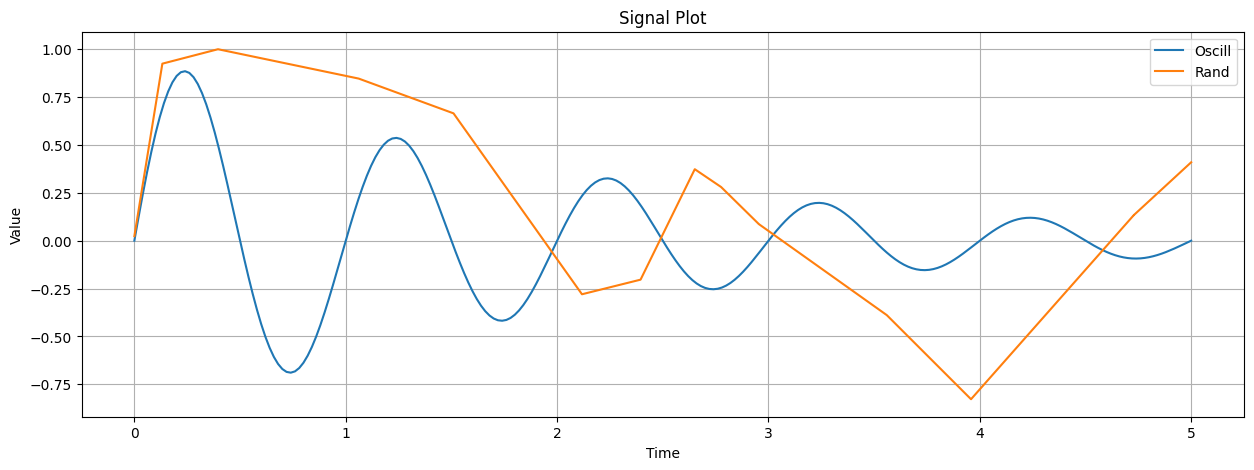

In [2]:
osc_gen = OscillSignalGen()
rand_gen = RandSignalGen(seed=1, interp='LINEAR', dt_min=0.02, dt_max=0.8, v_min=-1, v_max=1)

sin_sig = osc_gen.get_signal(t0=0, tf=5, dt=0.02, damp=-0.5, period=1)
rand_sig = rand_gen.get_signal(t0=0, tf=5)

ax = sin_sig.plot(label='Oscill')
ax = rand_sig.plot(label='Rand', ax=ax)

In [3]:
driver = stl.STLDriver()
driver.parse_string(
    """
    signal x, y
    param a = 0, b = 0.5

    x_sup := x[t] > 0
    y_sup := y[t] > 0

    alw_x := alw_[a, b] x_sup
    ev_x  := ev_ [a, b] x_sup
    x_until_y := x_sup until_[a, b] y_sup

    hist_x := hist_[a,b] x_sup
    once_x := once_[a,b] x_sup
    """
)
driver.set_signals([sin_sig, rand_sig])
print(driver)

# STLDriver object defined as
signal x, y
param a=0, b=0.5

# With formulas:
alw_x:= alw_[a,b] (x[t] > 0)
ev_x:= ev_[a,b] (x[t] > 0)
hist_x:= hist_[a,b] (x[t] > 0)
once_x:= once_[a,b] (x[t] > 0)
x_sup:= x[t] > 0
x_until_y:= (x[t] > 0) until_[a,b] (y[t] > 0)
y_sup:= y[t] > 0

# Data:
# Signal x:
# 251 samples from t0=0 to t_end=5
# Signal y:
# 13 samples from t0=0 to t_end=5




hist_[0,0.5] (x[t] > 0) 0 4.5
hist_[0,0.5] (x[t] > 0) 0 5
hist_[0,0.5] (x[t] > 0) 0.5 4.5
hist_[0,0.5] (x[t] > 0) 0.5 5
hist_[0.3,0.8] (x[t] > 0) 0 4.5
hist_[0.3,0.8] (x[t] > 0) 0 5
hist_[0.3,0.8] (x[t] > 0) 0.5 4.5
hist_[0.3,0.8] (x[t] > 0) 0.5 5
once_[0,0.5] (x[t] > 0) 0 4.5
once_[0,0.5] (x[t] > 0) 0 5
once_[0,0.5] (x[t] > 0) 0.5 4.5
once_[0,0.5] (x[t] > 0) 0.5 5
once_[0.3,0.8] (x[t] > 0) 0 4.5
once_[0.3,0.8] (x[t] > 0) 0 5
once_[0.3,0.8] (x[t] > 0) 0.5 4.5
once_[0.3,0.8] (x[t] > 0) 0.5 5


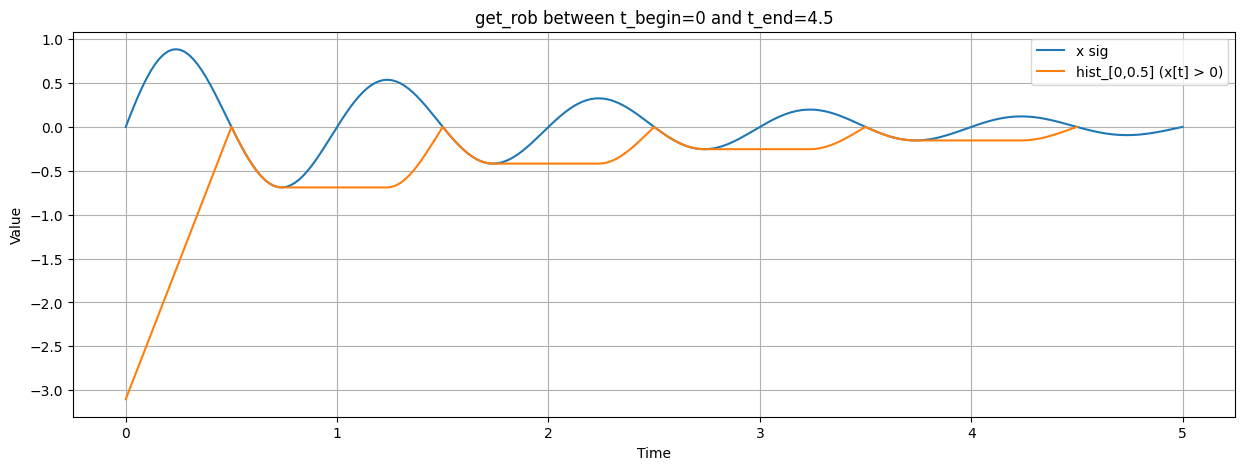

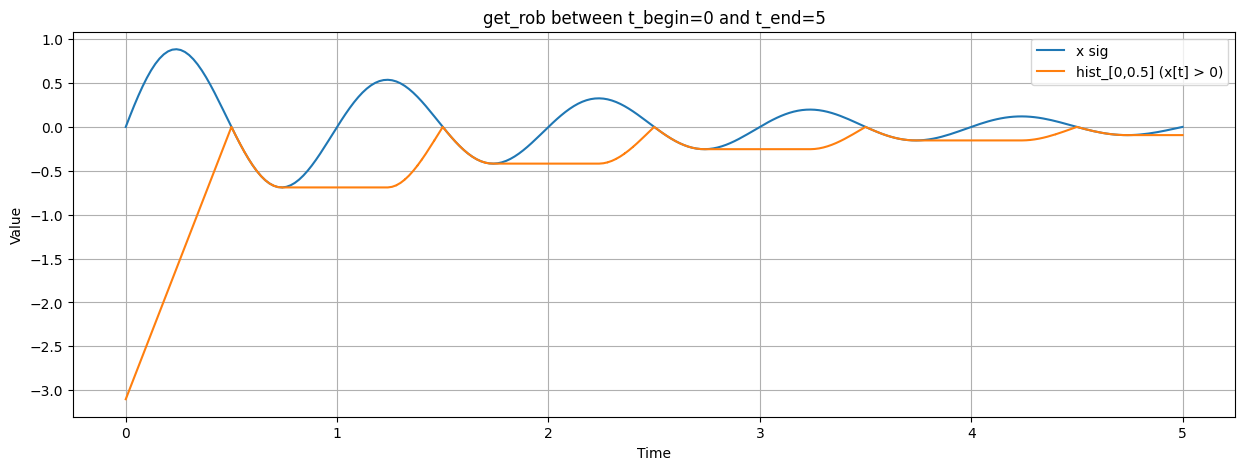

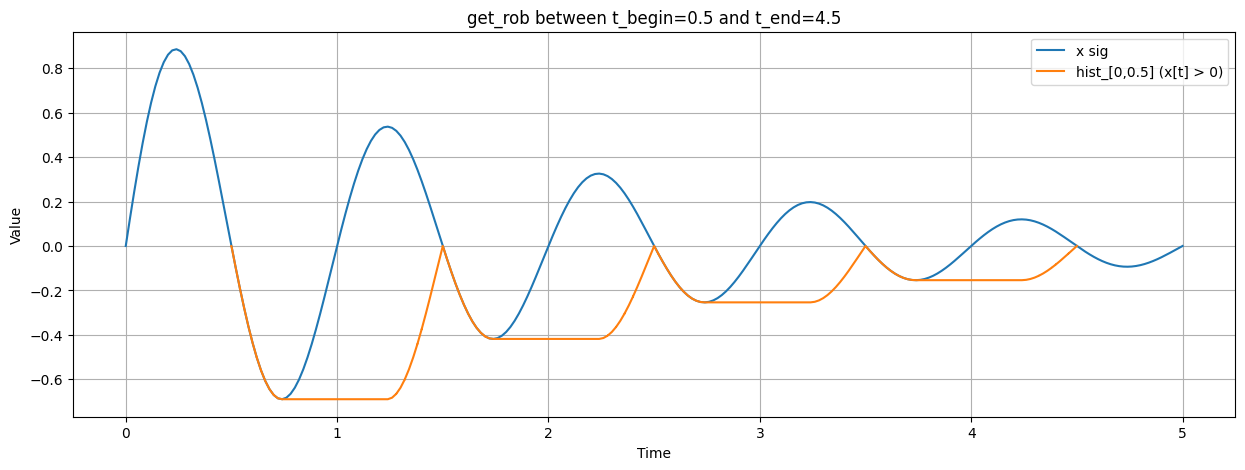

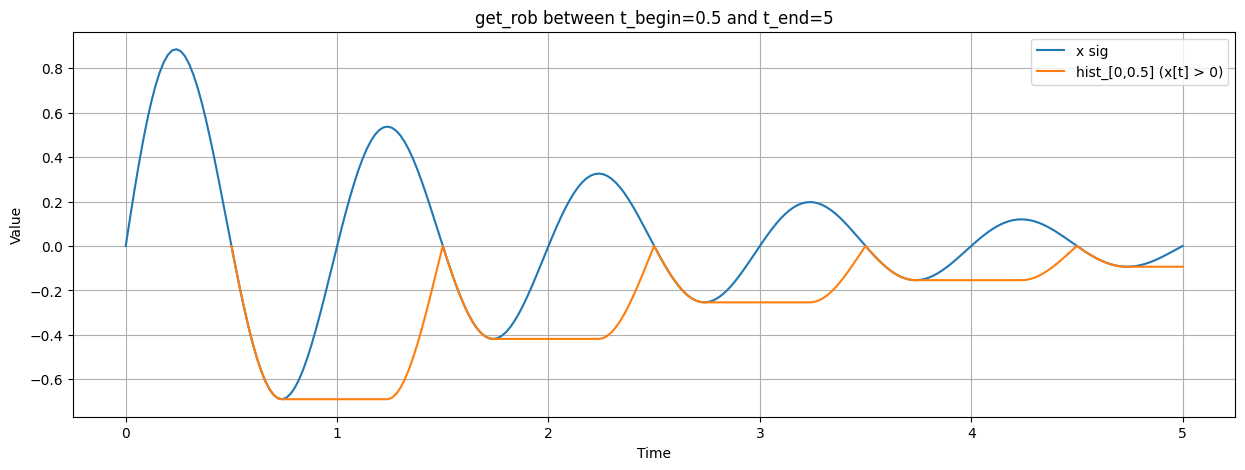

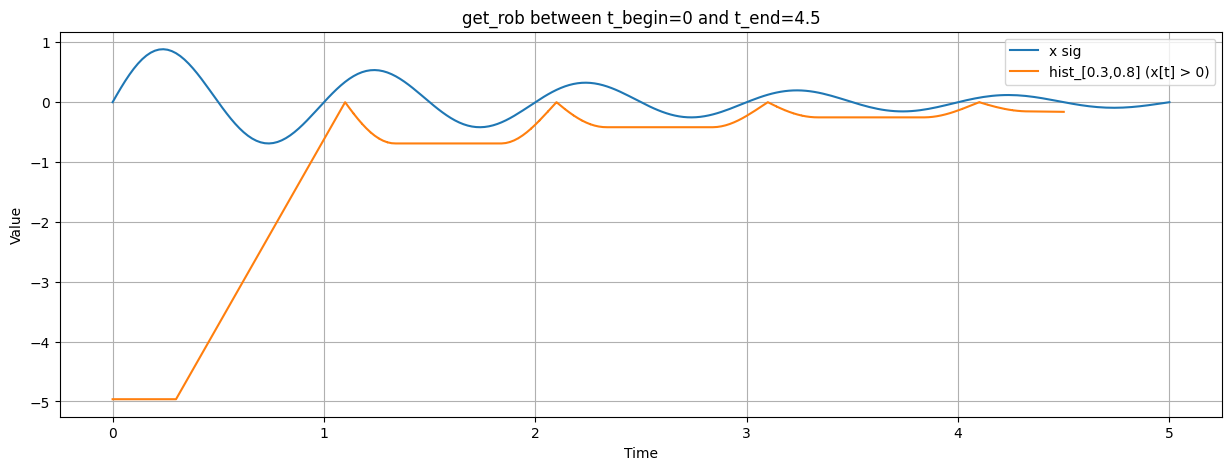

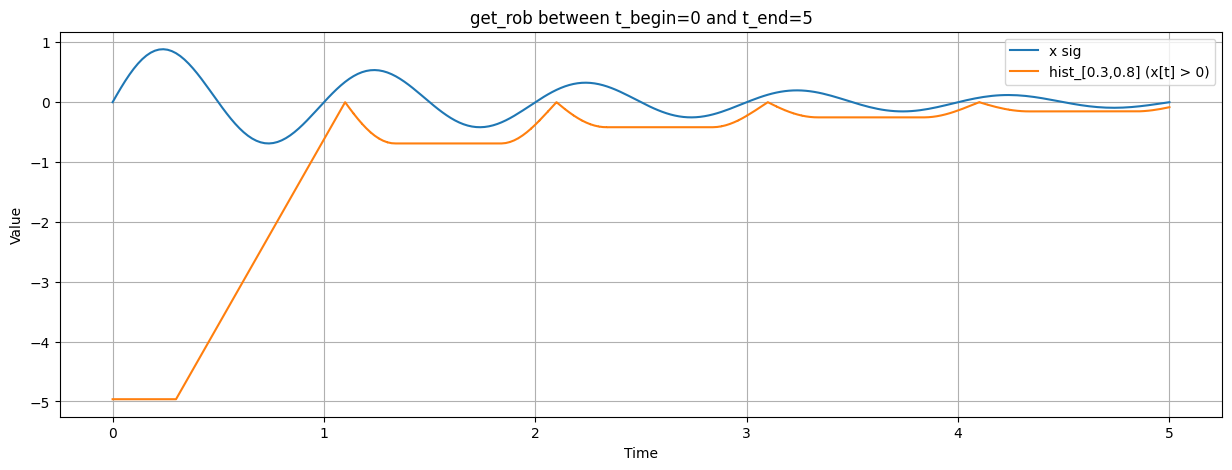

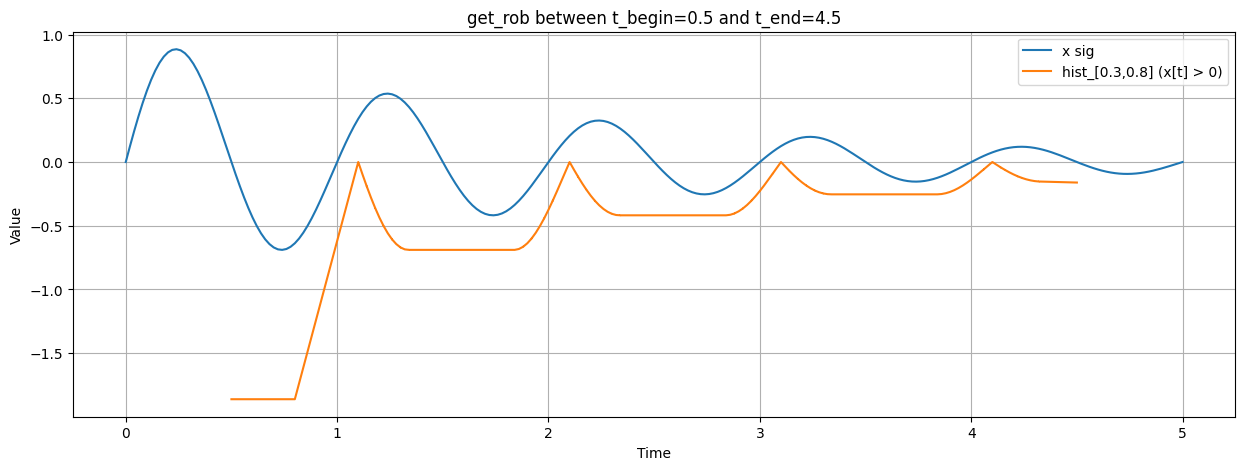

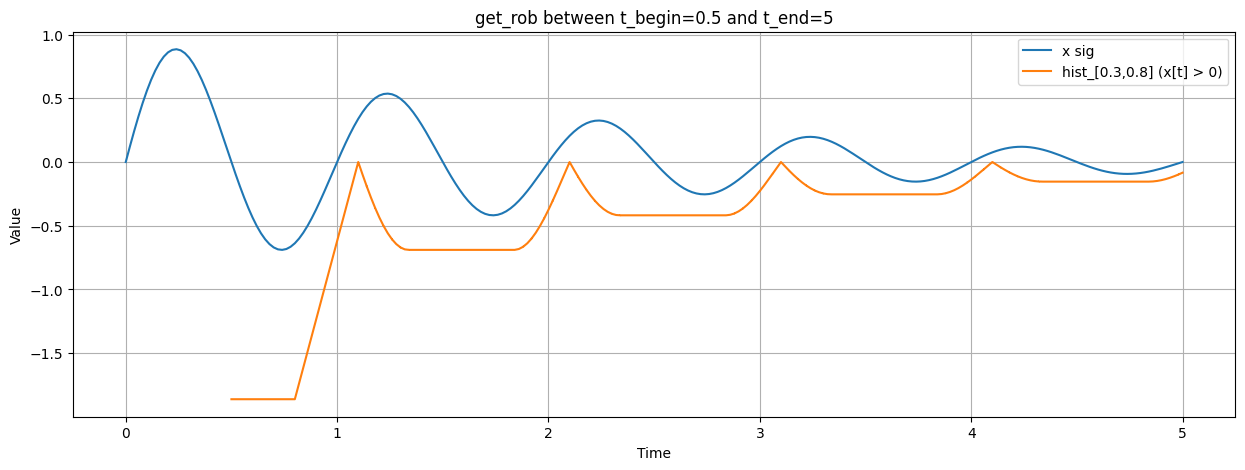

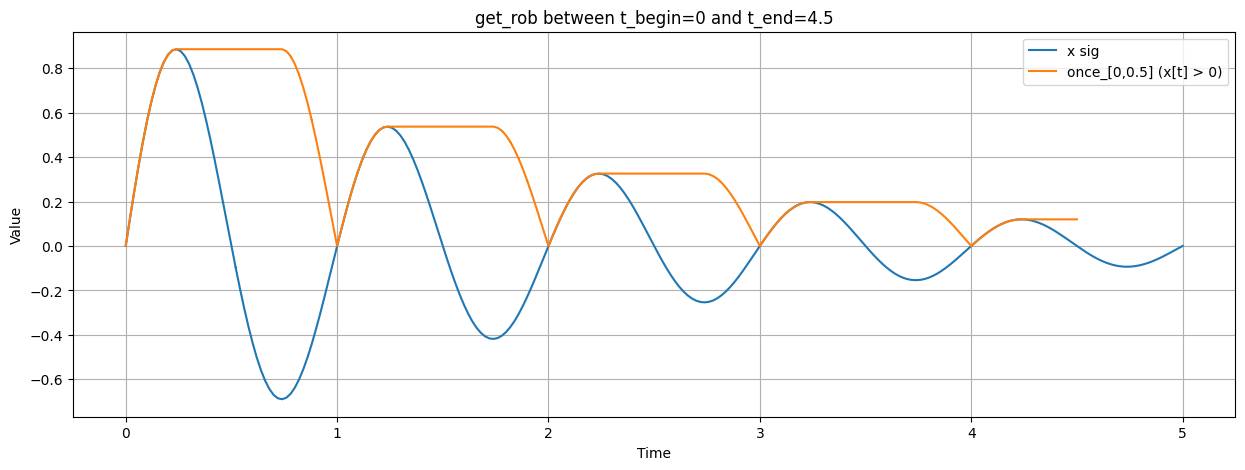

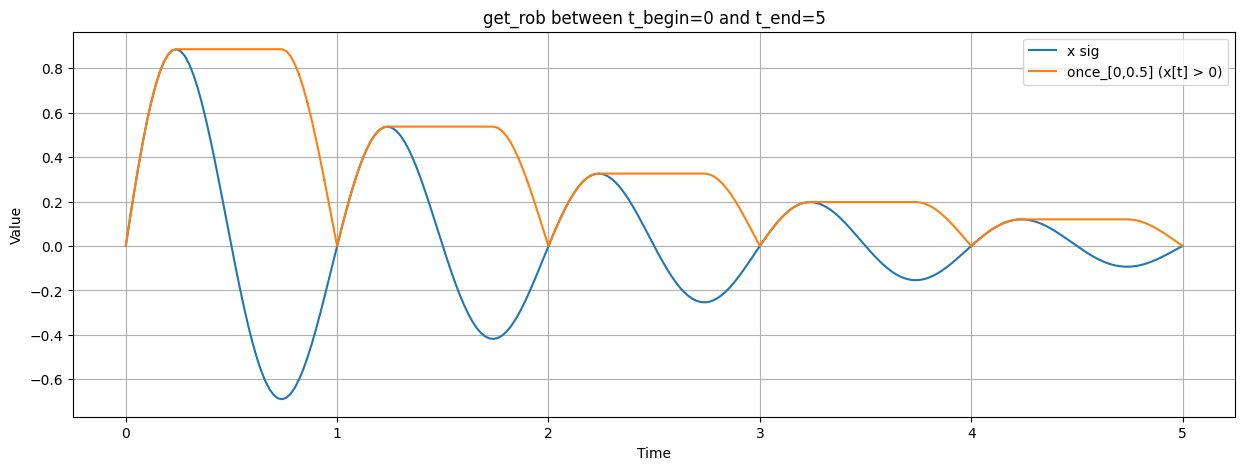

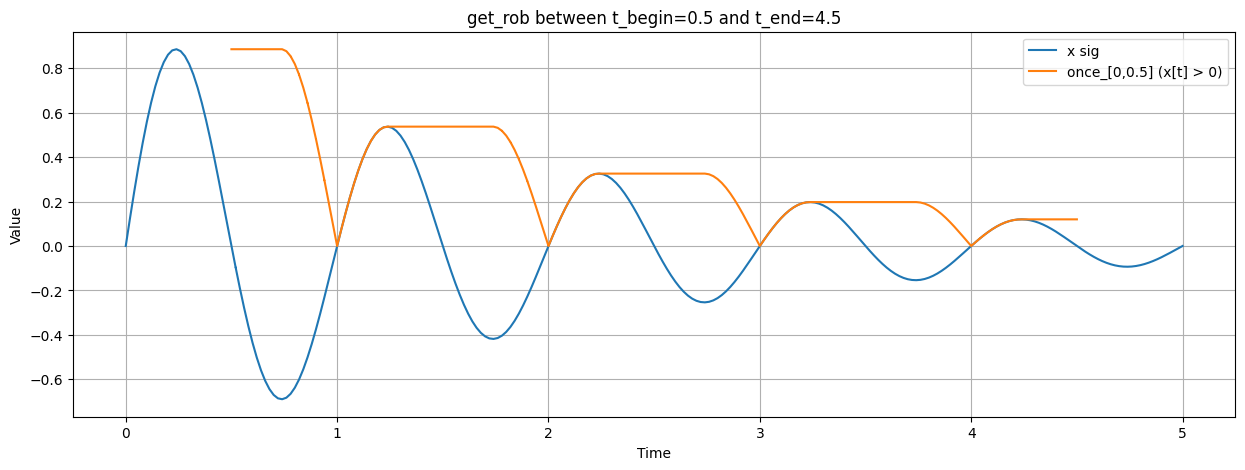

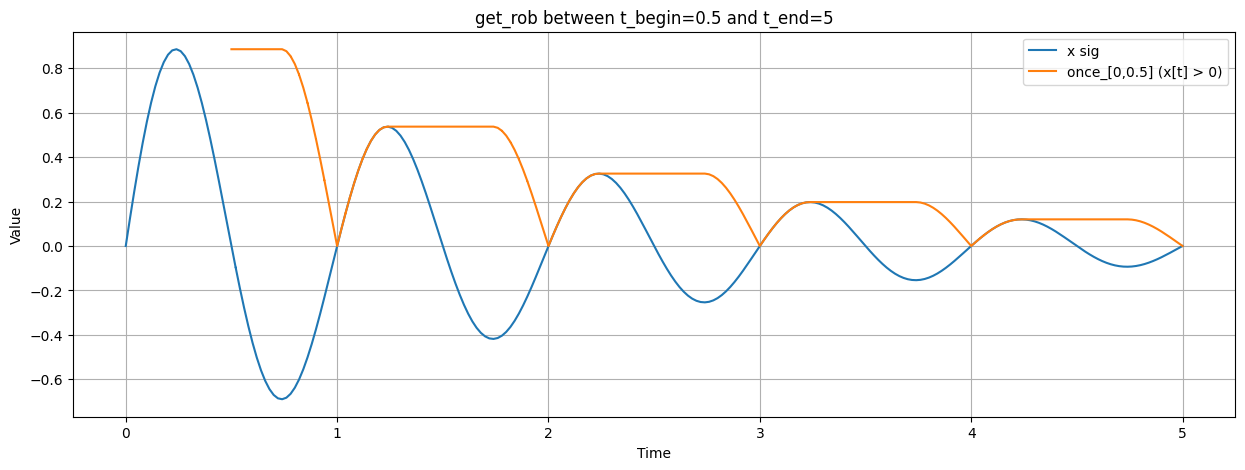

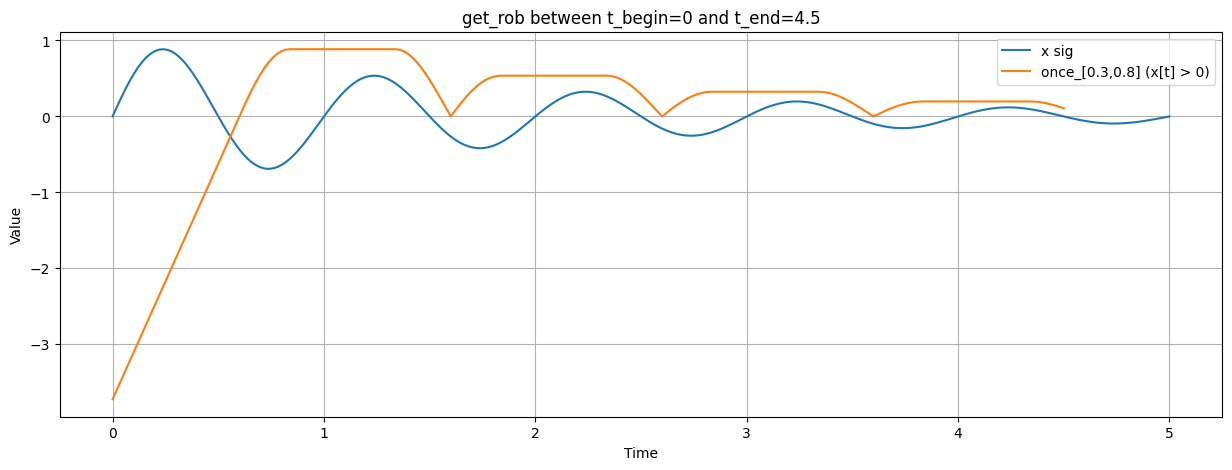

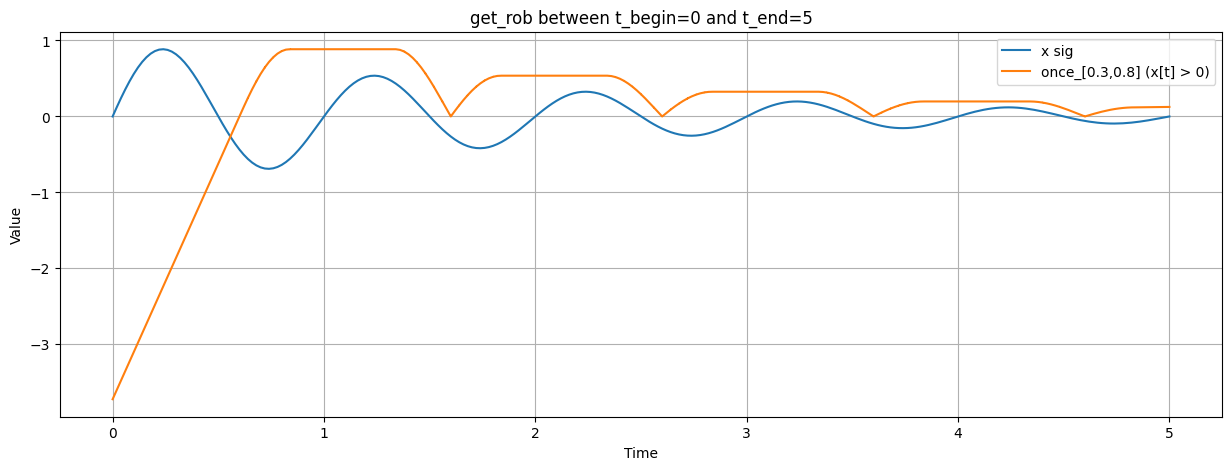

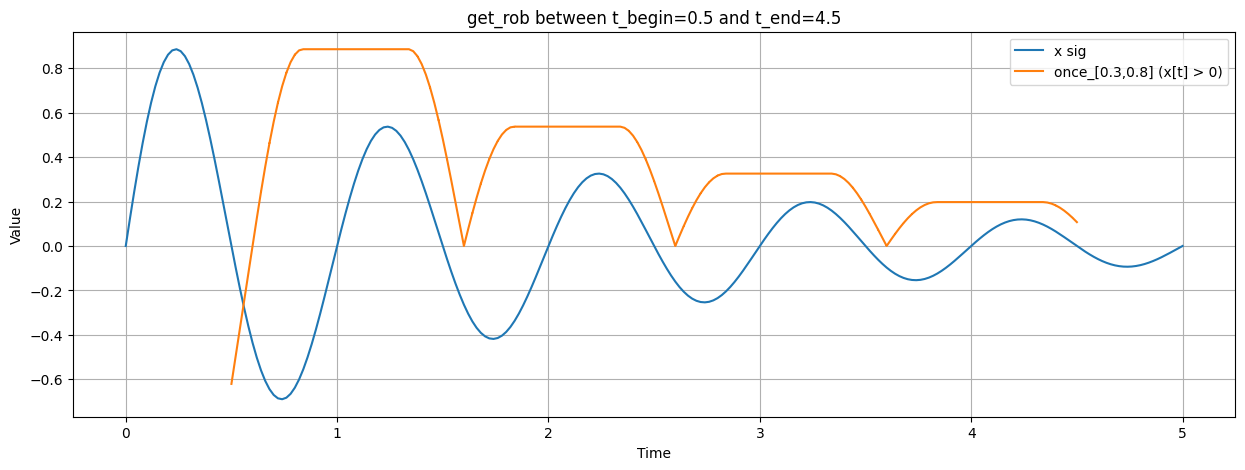

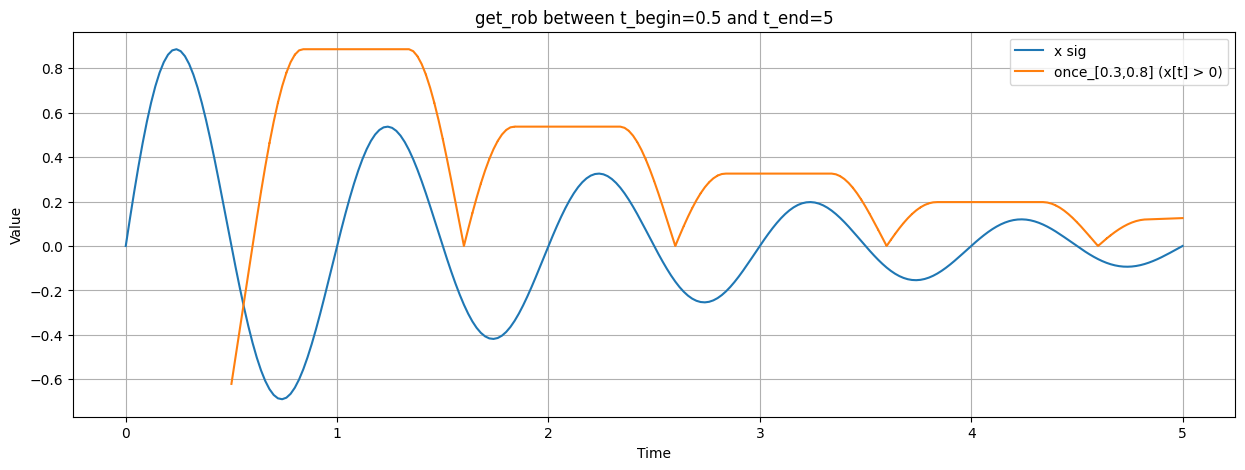

In [ ]:
phis_unary = ['alw_x', 'ev_x', 'hist_x', 'once_x']

params = [[0, 0.5], [0.3, 0.8]]
rob_windows = [[0, 4.5], [0, 5], [0.5, 4.5], [0.5, 5]]

for phi in phis_unary[2:]:
    monitor = driver.get_monitor(phi)
    for t_begin, t_end in rob_windows[0:]:
        monitor.set_param('a', a)
        monitor.set_param('b', b)
        for a, b in params[0:]:
            label = str(monitor.formula).replace('[a,b]', f'[{a},{b}]')
            print(label, t_begin, t_end)
            rob = monitor.get_rob_signal(t_begin, t_end)
            ax = sin_sig.plot(label = 'x sig')
            rob.plot(label = label, ax=ax)
            ax.set_title(f'get_rob between t_begin={t_begin} and t_end={t_end}')